In [37]:
# If not installed already (uncomment as needed):
# !pip install torch torch-geometric pandas tqdm

import os, json, torch, pandas as pd
from pathlib import Path
import importlib

import data_utils
importlib.reload(data_utils)

from data_utils import load_graphs, attach_labels_and_noisy, build_loaders
from train_loop import train, evaluate

In [18]:
# EDIT THESE:
GRAPHS_PT = "../processed/graphs_train.pt"      # <-- Step 1 output (a list[Data])
LABELS_CSV = "labels_train.csv"    # <-- We'll generate a template first if it doesn't exist
MODEL_OUT  = "qem_graph_transformer.pt"


In [19]:
graphs = load_graphs(GRAPHS_PT)
print(f"Loaded {len(graphs)} graphs")
# quick sanity on shapes
g0 = graphs[0]
print("x:", tuple(g0.x.shape),
      "edge_index:", tuple(g0.edge_index.shape),
      "lightcone_masks:", tuple(g0.lightcone_masks.shape))
M = g0.lightcone_masks.shape[1]
print("Measured qubits (M):", M)


Loaded 500 graphs
x: (2071, 20) edge_index: (2, 2565) lightcone_masks: (2071, 5)
Measured qubits (M): 5


In [ ]:
# This will create a template with circuit_path + zero arrays for noisy_z/target_y (len = M).
# If LABELS_CSV already exists, this cell won’t overwrite it unless you set FORCE=True.
FORCE = False

if (not Path(LABELS_CSV).exists()) or FORCE:
    rows = []
    for g in graphs:
        path = g.circuit_path if isinstance(g.circuit_path, str) else g.circuit_path[0]
        # Placeholder arrays (fill these with your real noisy/ideal values):
        zeros = [0.0] * g.lightcone_masks.shape[1]
        rows.append({
            "circuit_path": path,
            "noisy_z_json": json.dumps(zeros),
            "target_y_json": json.dumps(zeros)
        })
    df = pd.DataFrame(rows)
    df.to_csv(LABELS_CSV, index=False)
    print(f"Template written to {LABELS_CSV} with {len(df)} rows and M={M}.")
    display(df.head(3))
else:
    print(f"{LABELS_CSV} already exists — not overwriting. Set FORCE=True to regenerate.")


In [42]:
import data_utils
importlib.reload(data_utils)

from data_utils import load_graphs, attach_labels_and_noisy, build_loaders_by_train_val_paths

# Make sure you've filled LABELS_CSV before running this cell.
# graphs, M = attach_labels_and_noisy(graphs, LABELS_CSV)  # validates M consistency
# print(f"Graphs ready with labels. M={M}")


graphs = load_graphs(GRAPHS_PT)
graphs, M = attach_labels_and_noisy(graphs, "labels_train.csv")



# train_loader, val_loader = build_loaders(graphs, batch_size=4, val_frac=0.8, seed=42)

train_loader, val_loader = build_loaders_by_train_val_paths(
    graphs, train_data_paths, test_data_paths, batch_size=4, shuffle_train=False
)



len(train_loader), len(val_loader)


[build] train=100 | val=400 | M=5


(25, 100)

In [43]:
iterator = iter(train_loader)
batch = next(iterator)

In [44]:
batch

DataBatch(x=[64991, 20], edge_index=[2, 80827], num_nodes=64991, lightcone_masks=[64991, 5], measured_qubits=[20], num_measured=[4], num_qubits=[4], depth_layers=[4], circuit_path=[4], split=[4], noisy_z=[20], y=[20], batch=[64991], ptr=[5])

In [45]:
# You can tune these a bit; keep it small because of low data.
model_cfg = dict(d_model=128, layers=3, heads=4, dropout=0.1, use_noisy=True)

net, hist = train(model_cfg, (train_loader, val_loader),
                  epochs=100, lr=1e-3, wd=1e-4, patience=15,
                  best_ckpt_path="best_qem_graph_transformer.pt")

# net is already restored to the best-validated state

# torch.save(net.state_dict(), MODEL_OUT)
# print("Saved:", MODEL_OUT)


Epoch 001 | train 0.0675 | val 0.0415 | MAE 0.2102
Epoch 002 | train 0.0605 | val 0.0370 | MAE 0.1924
Epoch 003 | train 0.0561 | val 0.0415 | MAE 0.2258
Epoch 004 | train 0.0525 | val 0.0338 | MAE 0.1728
Epoch 005 | train 0.0501 | val 0.0310 | MAE 0.1654
Epoch 006 | train 0.0476 | val 0.0289 | MAE 0.1659
Epoch 007 | train 0.0446 | val 0.0295 | MAE 0.1880
Epoch 008 | train 0.0430 | val 0.0248 | MAE 0.1670
Epoch 009 | train 0.0348 | val 0.0215 | MAE 0.1665
Epoch 010 | train 0.0315 | val 0.0212 | MAE 0.1760
Epoch 011 | train 0.0283 | val 0.0185 | MAE 0.1680
Epoch 012 | train 0.0218 | val 0.0125 | MAE 0.1394
Epoch 013 | train 0.0173 | val 0.0075 | MAE 0.1049
Epoch 014 | train 0.0128 | val 0.0035 | MAE 0.0614
Epoch 015 | train 0.0086 | val 0.0021 | MAE 0.0401
Epoch 016 | train 0.0057 | val 0.0018 | MAE 0.0446
Epoch 017 | train 0.0036 | val 0.0009 | MAE 0.0285
Epoch 018 | train 0.0028 | val 0.0007 | MAE 0.0266
Epoch 019 | train 0.0024 | val 0.0009 | MAE 0.0322
Epoch 020 | train 0.0033 | val 

In [46]:
import torch.nn as nn
crit = nn.SmoothL1Loss()
device = "cuda" if torch.cuda.is_available() else "cpu"
metrics = evaluate(net, val_loader, crit, device=device)
metrics


{'loss': 0.0003490287343447562, 'mae': 0.01774608129635453}

Per-qubit MAE (model): [0.018647268414497375, 0.017297696322202682, 0.018063612282276154, 0.017123231664299965, 0.017598601058125496]


/tmp/ipykernel_810800/3332857812.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


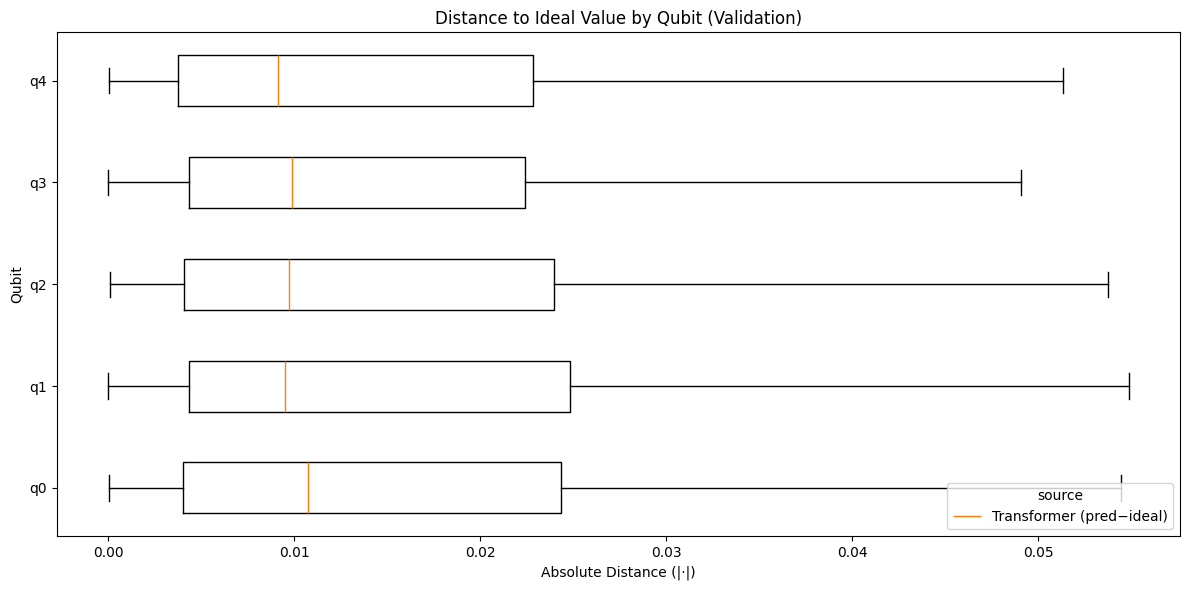

In [47]:
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
M = next(iter(val_loader)).lightcone_masks.shape[1]

@torch.no_grad()
def collect_pred_target_noisy(loader, model, M, device):
    model.eval()
    P, Y, N = [], [], []
    for batch in loader:
        batch = batch.to(device)
        y_hat = model(batch)            # [B*M]
        P.append(y_hat.detach().cpu())
        Y.append(batch.y.detach().cpu())
        N.append(batch.noisy_z.detach().cpu())
    P = torch.cat(P, 0).view(-1, M)     # [S, M]
    Y = torch.cat(Y, 0).view(-1, M)     # [S, M]
    N = torch.cat(N, 0).view(-1, M)     # [S, M]
    return P, Y, N

P, Y, N = collect_pred_target_noisy(val_loader, net, M, device)

# ---- Per-qubit MAE (model) ----
per_qubit_mae = (P - Y).abs().mean(dim=0).tolist()
print("Per-qubit MAE (model):", per_qubit_mae)

# ---- Distances to plot ----
dist_model = (P - Y).abs()   # what you want on the plot
dist_noisy = (N - Y).abs()   # optional baseline

def plot_distance_boxplot(dist_by_source, qubit_labels=None, title="Distance to Ideal by Qubit"):
    first = next(iter(dist_by_source.values()))
    S, M = first.shape
    if qubit_labels is None:
        qubit_labels = [f"q{i}" for i in range(M)]

    fig = plt.figure(figsize=(12, 6))
    ax = plt.gca()
    base_positions = torch.arange(M).float()
    K = len(dist_by_source)
    offsets = torch.linspace(-0.25, 0.25, steps=K) if K > 1 else torch.tensor([0.0])

    handles = []
    for j, (name, D) in enumerate(dist_by_source.items()):
        data = [D[:, q].numpy() for q in range(M)]
        positions = (base_positions + offsets[j]).tolist()
        bp = ax.boxplot(
            data,
            positions=positions,
            vert=False,
            widths=0.5,
            patch_artist=False,
            manage_ticks=False,
            showfliers=False,
            whis=1.5,
            labels=None,
        )
        handles.append(bp["medians"][0])

    ax.set_yticks(base_positions.tolist())
    ax.set_yticklabels(qubit_labels)
    ax.set_xlabel("Absolute Distance (|·|)")
    ax.set_ylabel("Qubit")
    ax.set_title(title)
    ax.legend(handles, list(dist_by_source.keys()), loc="lower right", title="source")
    fig.tight_layout()
    plt.show()

# ---- Plot (model vs optional baseline) ----
plot_distance_boxplot(
    {
        "Transformer (pred−ideal)": dist_model,
        # "Noisy (noisy−ideal)": dist_noisy,   # uncomment to compare baseline
    },
    qubit_labels=[f"q{i}" for i in range(M)],
    title="Distance to Ideal Value by Qubit (Validation)",
)


In [14]:
import json
import numpy as np

def boxplot_stats_from_tensor(D):
    """Return per-qubit boxplot statistics from [S, M] tensor."""
    stats = []
    for q in range(D.shape[1]):
        arr = D[:, q].numpy()
        q1 = np.percentile(arr, 25)
        q3 = np.percentile(arr, 75)
        median = np.median(arr)
        whisker_low = arr[arr >= q1 - 1.5 * (q3 - q1)].min()
        whisker_high = arr[arr <= q3 + 1.5 * (q3 - q1)].max()
        stats.append({
            "qbit": int(q),
            "q1": float(q1),
            "q3": float(q3),
            "median": float(median),
            "whisker_low": float(whisker_low),
            "whisker_high": float(whisker_high),
        })
    return stats

# Example: save for model distances
stats_model = boxplot_stats_from_tensor(dist_model)
stats_noisy = boxplot_stats_from_tensor(dist_noisy)

# Save to JSON
save_path = "boxplot_stats.json"
with open(save_path, "w") as f:
    json.dump({
        "Transformer (pred−ideal)": stats_model,
        "Noisy (noisy−ideal)": stats_noisy,
    }, f, indent=2)
print(f"Saved stats to {save_path}")


Saved stats to boxplot_stats.json


# Comparison

In [7]:
import json, os, pickle
import numpy as np
from tqdm.notebook import tqdm
import pandas as pd

import torch
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import qiskit.circuit.random
import torch, random
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn

import numpy as np
import json, os, pickle
from tqdm import tqdm
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from qiskit import QuantumCircuit

import sys
sys.path.append('../../../tutorials/')
from mlp import encode_data, encode_data_v2_ecr

In [22]:
def check_f(f, f_ext, step_indices):
    return f.endswith(f_ext) and any([f"step_%02d"%step_index in f for step_index in step_indices])

def load_circuits(data_dir, step_indices, f_ext='.pk'):
    Js = []
    circuits = []
    data_paths = []
    data_files = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if check_f(f, f_ext, step_indices)])
    for data_file in tqdm(data_files, leave=True):
        for entry in pickle.load(open(data_file, 'rb')):
            Js.append(entry['J'])
            circuits.append(entry['circuit'])
        data_paths.append(data_file[3:])
    return data_paths, circuits, Js

In [23]:
data_paths, circuits, Js = load_circuits('../../../tutorials/data/ising_zne_hardware/100q_brisbane/', list(range(1, 11)))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:42<00:00, 11.68it/s]


In [24]:
data_paths[0]

'../../tutorials/data/ising_zne_hardware/100q_brisbane/step_01_J00.pk'

In [25]:
for step_index in [1]:
    with open('../../../tutorials/zne_mitigated/twirl_100q_brisbane/step%02d.json'%step_index, 'r') as file:
        loaded = json.load(file)
    noise_factor_1 = np.array(loaded['noise_factor_1'])
    noise_factor_3 = np.array(loaded['noise_factor_3'])

for step_index in tqdm([2, 3, 4, 5, 6, 7, 8, 9, 10]):
    with open('../../../tutorials/zne_mitigated/twirl_100q_brisbane/step%02d.json'%step_index, 'r') as file:
        loaded = json.load(file)
    noise_factor_1 = np.concatenate([noise_factor_1, loaded['noise_factor_1']])
    noise_factor_3 = np.concatenate([noise_factor_3, loaded['noise_factor_3']])

noise_factor_1_tw_avg = noise_factor_1.reshape(noise_factor_1.shape[0], 5, 5).mean(axis=-1)
noise_factor_3_tw_avg = noise_factor_3.reshape(noise_factor_3.shape[0], 5, 5).mean(axis=-1)

slope = (noise_factor_3_tw_avg - noise_factor_1_tw_avg) / 2
zne_mitigated_vals = (noise_factor_1_tw_avg - slope).tolist()
noisy_vals = noise_factor_1_tw_avg.tolist()
len(zne_mitigated_vals)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 721.04it/s]


500

In [26]:
print(len(circuits), len(zne_mitigated_vals), len(noisy_vals), len(data_paths))

500 500 500 500


In [27]:
num_circ_per_step = 50
k = train_test_split = 10
train_circuits = []
train_zne_vals = []
train_data_paths = []
train_noisy_vals = []
test_circuits = []
test_data_paths = []
test_zne_vals = []
test_noisy_vals = []
test_Js = []
for start_each_step in list(range(len(circuits))[::num_circ_per_step]):
    train_circuits += circuits[start_each_step:start_each_step+k]
    train_data_paths += data_paths[start_each_step:start_each_step+k]
    train_zne_vals += zne_mitigated_vals[start_each_step:start_each_step+k]
    train_noisy_vals += noisy_vals[start_each_step:start_each_step+k]
    test_circuits += circuits[start_each_step+k:start_each_step+num_circ_per_step]
    test_data_paths += data_paths[start_each_step+k:start_each_step+num_circ_per_step]
    test_zne_vals += zne_mitigated_vals[start_each_step+k:start_each_step+num_circ_per_step]
    test_noisy_vals += noisy_vals[start_each_step+k:start_each_step+num_circ_per_step]
    test_Js += Js[start_each_step+k:start_each_step+num_circ_per_step]

In [28]:
print(len(train_circuits), len(train_zne_vals), len(train_noisy_vals), len(train_data_paths))
print(len(test_circuits), len(test_zne_vals), len(test_noisy_vals), len(test_data_paths))

100 100 100 100
400 400 400 400


In [48]:
few_normal_X_train, few_normal_y_train = encode_data_v2_ecr(train_circuits, train_zne_vals, train_noisy_vals, obs_size=5)
few_normal_X_test, few_normal_y_test = encode_data_v2_ecr(test_circuits, test_zne_vals, test_noisy_vals, obs_size=5)

In [49]:
BATCH_SIZE = 32
few_normal_train_dataset = TensorDataset(torch.Tensor(few_normal_X_train), torch.Tensor(few_normal_y_train))
few_normal_train_loader = DataLoader(few_normal_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
few_normal_test_dataset = TensorDataset(torch.Tensor(few_normal_X_test), torch.Tensor(few_normal_y_test))
few_normal_test_loader = DataLoader(few_normal_test_dataset, batch_size=BATCH_SIZE*1000, shuffle=False)

In [50]:
few_normal_X_train = pd.DataFrame(few_normal_X_train)
few_normal_y_train = pd.DataFrame(few_normal_y_train)
few_normal_X_test = pd.DataFrame(few_normal_X_test)
few_normal_y_test = pd.DataFrame(few_normal_y_test)

In [51]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

few_normal_rfr_tree_list = []
for q in range(5):
    rfr = RandomForestRegressor(n_estimators=100, verbose=0, n_jobs=-1)
    rfr.fit(few_normal_X_train, few_normal_y_train.iloc[:, q])
    few_normal_rfr_tree_list.append(rfr)
    print(f"Done with the {q} model")

Done with the 0 model
Done with the 1 model
Done with the 2 model
Done with the 3 model
Done with the 4 model


RMSE_noisy_0: 0.06622940680866209
RMSE_mitigated_0: 0.03165915115542441
RMSE_noisy_1: 0.06571337924238625
RMSE_mitigated_1: 0.031626901816404034
RMSE_noisy_2: 0.0654646813056526
RMSE_mitigated_2: 0.03403869844286336
RMSE_noisy_3: 0.06489176308232669
RMSE_mitigated_3: 0.03781960478740562
RMSE_noisy_4: 0.06681302970392002
RMSE_mitigated_4: 0.0384238307681622
RMSE_noisy: 0.0655765734696172
RMSE_mitigated: 0.033880371413054985


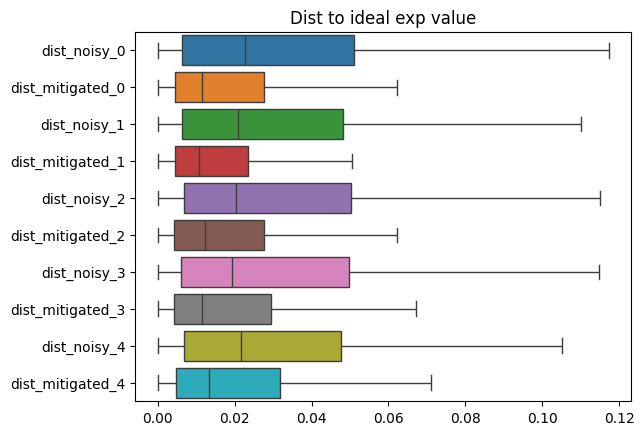

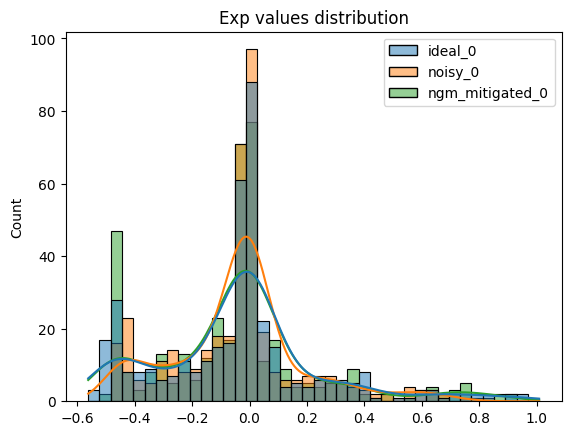

In [52]:
distances = []

num_spins = 5

for batch_X, batch_y in few_normal_test_loader:
    out = []
    for q, model in enumerate(few_normal_rfr_tree_list):
        out.append(model.predict(batch_X[:, :]))
    out = np.array(out).transpose()

    for ideal, noisy, ngm_mitigated in zip(
        batch_y.tolist(),
        batch_X[:, -5:].tolist(),
        out.tolist()
    ):
        for q in range(5):
            ideal_q = ideal[q]
            noisy_q = noisy[q]
            ngm_mitigated_q = ngm_mitigated[q]
            distances.append({
                f"ideal_{q}": ideal_q,
                f"noisy_{q}": noisy_q,
                f"ngm_mitigated_{q}": ngm_mitigated_q,
                f"dist_noisy_{q}": np.abs(ideal_q - noisy_q),
                f"dist_mitigated_{q}": np.abs(ideal_q - ngm_mitigated_q),
                f"dist_sq_noisy_{q}": np.square(ideal_q - noisy_q),
                f"dist_sq_mitigated_{q}": np.square(ideal_q - ngm_mitigated_q),
            })

plt.style.use({'figure.facecolor':'white'})

df = pd.DataFrame(distances)

for q in range(5):
    print(f'RMSE_noisy_{q}:', np.sqrt(df[f"dist_sq_noisy_{q}"].mean()))
    print(f'RMSE_mitigated_{q}:', np.sqrt(df[f"dist_sq_mitigated_{q}"].mean()))

print(f'RMSE_noisy:', np.sqrt(np.mean([df[f"dist_sq_noisy_{q}"].mean() for q in range(4)])))
print(f'RMSE_mitigated:', np.sqrt(np.mean([df[f"dist_sq_mitigated_{q}"].mean() for q in range(4)])))

sns.boxplot(data=df[["dist_noisy_0", "dist_mitigated_0", "dist_noisy_1", "dist_mitigated_1", "dist_noisy_2", "dist_mitigated_2", "dist_noisy_3", "dist_mitigated_3", "dist_noisy_4", "dist_mitigated_4"]], orient="h", showfliers = False)
plt.title("Dist to ideal exp value")
plt.show()

sns.histplot([df['ideal_0'], df['noisy_0'], df["ngm_mitigated_0"]], kde=True, bins=40)
plt.title("Exp values distribution")
plt.show()

In [53]:
def evaluate_loader(test_loader, model_list, label: str, n_qbits=5):
    results = []

    for batch_X, batch_y in test_loader:
        predictions = []
        for q, model in enumerate(model_list):
            predictions.append(model.predict(batch_X[:, :]))
        predictions = np.array(predictions).transpose()

        for ideal, noisy_or_normal, mitigated in zip(
            batch_y.tolist(),
            batch_X[:, -5:].tolist(),
            predictions.tolist()
        ):
            for q in range(n_qbits):
                ideal_q = ideal[q]
                noisy_q = noisy_or_normal[q]
                mitigated_q = mitigated[q]

                results.append({
                    "source": label,
                    f"ideal_{q}": ideal_q,
                    f"input_{q}": noisy_q,
                    f"mitigated_{q}": mitigated_q,
                    f"dist_{q}": np.abs(ideal_q - noisy_q),
                    f"dist_mitigated_{q}": np.abs(ideal_q - mitigated_q),
                    f"dist_sq_{q}": np.square(ideal_q - noisy_q),
                    f"dist_sq_mitigated_{q}": np.square(ideal_q - mitigated_q),
                })
    return results

import torch
import numpy as np

def evaluate_pyg_loader(pyg_loader, net, label: str, n_qbits=5, device=None):
    """
    Produces a list[dict] with the same keys as your RF evaluate_loader().
    - 'input' = noisy_z
    - 'mitigated' = model prediction
    - 'ideal' = y (target)
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    net.eval()
    results = []
    with torch.no_grad():
        for batch in pyg_loader:
            batch = batch.to(device)
            # Shapes: y_hat, y, noisy are [B*M]; we'll reshape to [B, M]
            y_hat = net(batch).detach().cpu()
            y     = batch.y.detach().cpu()
            noisy = batch.noisy_z.detach().cpu()

            # infer M from masks
            M = batch.lightcone_masks.shape[1]
            B = y_hat.numel() // M

            y_hat = y_hat.view(B, M).numpy()
            y     = y.view(B, M).numpy()
            noisy = noisy.view(B, M).numpy()

            for ideal_row, noisy_row, mitig_row in zip(y, noisy, y_hat):
                row = {"source": label}
                for q in range(n_qbits):
                    ideal_q     = float(ideal_row[q])
                    noisy_q     = float(noisy_row[q])
                    mitigated_q = float(mitig_row[q])
                    row.update({
                        f"ideal_{q}": ideal_q,
                        f"input_{q}": noisy_q,
                        f"mitigated_{q}": mitigated_q,
                        f"dist_{q}": abs(ideal_q - noisy_q),
                        f"dist_mitigated_{q}": abs(ideal_q - mitigated_q),
                        f"dist_sq_{q}": (ideal_q - noisy_q) ** 2,
                        f"dist_sq_mitigated_{q}": (ideal_q - mitigated_q) ** 2,
                    })
                results.append(row)
    return results


In [54]:
few_normal_results = evaluate_loader(few_normal_test_loader, few_normal_rfr_tree_list, label="RF+FewData")
gnn_val_results = evaluate_pyg_loader(val_loader, net, label="GraphTransMLP+FewData", n_qbits=5)

all_results = few_normal_results + gnn_val_results
df = pd.DataFrame(all_results)

In [55]:
for q in range(5):
    for label in ["RF+CLIP+LargeData", "RF+LargeData", "RF+FewData", "RF+SimulatedAndrewData", "RF+RealAndrewData", "GraphTransMLP+FewData"]:
        subset = df[df["source"] == label]
        rmse = np.sqrt(subset[f"dist_sq_{q}"].mean())
        rmse_mitigated = np.sqrt(subset[f"dist_sq_mitigated_{q}"].mean())
        print(f"[{label}] RMSE_input_{q}: {rmse:.4f}, RMSE_mitigated_{q}: {rmse_mitigated:.4f}")

print("------ Overall RMSEs ------")
for label in ["RF+CLIP+LargeData", "RF+LargeData", "RF+FewData", "RF+SimulatedAndrewData", "RF+RealAndrewData", "GraphTransMLP+FewData"]:
    subset = df[df["source"] == label]
    rmse = np.sqrt(np.mean([subset[f"dist_sq_{q}"].mean() for q in range(5)]))
    rmse_mitigated = np.sqrt(np.mean([subset[f"dist_sq_mitigated_{q}"].mean() for q in range(5)]))
    print(f"[{label}] RMSE_input: {rmse:.4f}, RMSE_mitigated: {rmse_mitigated:.4f}")



[RF+CLIP+LargeData] RMSE_input_0: nan, RMSE_mitigated_0: nan
[RF+LargeData] RMSE_input_0: nan, RMSE_mitigated_0: nan
[RF+FewData] RMSE_input_0: 0.0662, RMSE_mitigated_0: 0.0317
[RF+SimulatedAndrewData] RMSE_input_0: nan, RMSE_mitigated_0: nan
[RF+RealAndrewData] RMSE_input_0: nan, RMSE_mitigated_0: nan
[GraphTransMLP+FewData] RMSE_input_0: 0.0662, RMSE_mitigated_0: 0.0281
[RF+CLIP+LargeData] RMSE_input_1: nan, RMSE_mitigated_1: nan
[RF+LargeData] RMSE_input_1: nan, RMSE_mitigated_1: nan
[RF+FewData] RMSE_input_1: 0.0657, RMSE_mitigated_1: 0.0316
[RF+SimulatedAndrewData] RMSE_input_1: nan, RMSE_mitigated_1: nan
[RF+RealAndrewData] RMSE_input_1: nan, RMSE_mitigated_1: nan
[GraphTransMLP+FewData] RMSE_input_1: 0.0657, RMSE_mitigated_1: 0.0251
[RF+CLIP+LargeData] RMSE_input_2: nan, RMSE_mitigated_2: nan
[RF+LargeData] RMSE_input_2: nan, RMSE_mitigated_2: nan
[RF+FewData] RMSE_input_2: 0.0655, RMSE_mitigated_2: 0.0340
[RF+SimulatedAndrewData] RMSE_input_2: nan, RMSE_mitigated_2: nan
[RF+Rea

/home/macula/SMATousi/.conda/envs/mlqem-old-version/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


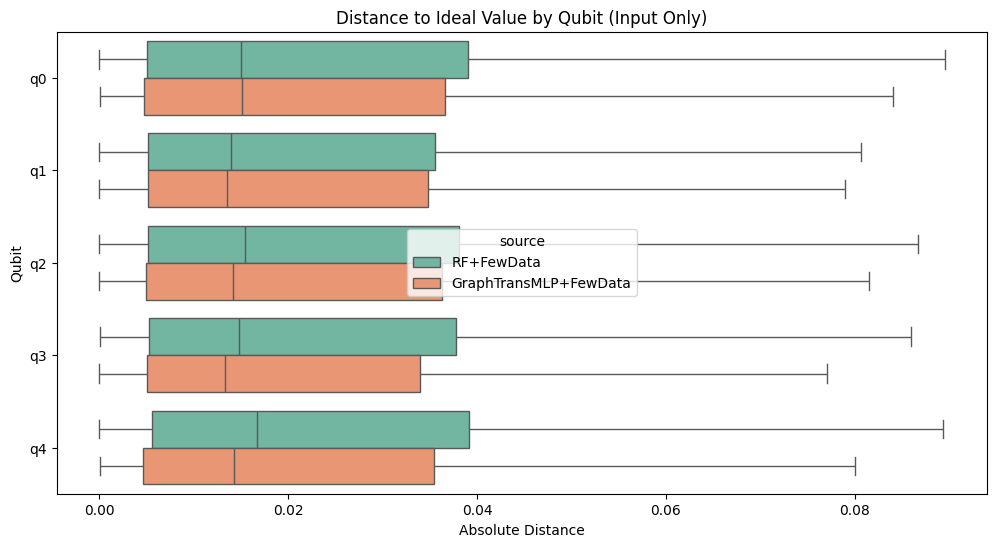

In [57]:
melted = pd.DataFrame()

for q in range(5):
    for metric in ["dist", "dist_mitigated"]:
        temp = df[[f"{metric}_{q}", "source"]].copy()
        temp = temp.rename(columns={f"{metric}_{q}": "value"})
        temp["qubit"] = f"q{q}"
        temp["type"] = "input" if "dist_" == metric else "mitigated"
        melted = pd.concat([melted, temp], ignore_index=True)

plt.figure(figsize=(12, 6))
sns.boxplot(data=melted, x="value", y="qubit", hue="source", palette="Set2", showfliers=False)
plt.title("Distance to Ideal Value by Qubit (Input Only)")
plt.xlabel("Absolute Distance")
plt.ylabel("Qubit")
plt.savefig("RF-vs-GTrains.png")
plt.show()
